In [ ]:
                                                     # ------ IRIS ------ #

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.datasets import load_iris
import pandas as pd

# Load dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Save as CSV
df.to_csv('Iris.csv', index=False)

print("Iris.csv file created!")

Iris.csv file created!


In [8]:
import pandas as pd
df = pd.read_csv('Iris.csv')
df.head()

# Installs/updates the ydata-profiling library
# This tool automatically generates a complete data analysis report
!pip install -U ydata-profiling

# The library scans your dataset and analyzes:

# Data types
# Missing values
# Distributions
# Correlations
# Outliers
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="My Data Profile")

# Creates an HTML file: my_data_profile.html
# You can open it in your browser
profile.to_file("my_data_profile.html")

  Using cached ydata_profiling-4.18.1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached phik-0.12.5-cp313-cp313-win_amd64.whl.metadata (5.6 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
Using cached ydata_profiling-4.18.1-py2.py3-none-any.whl (400 kB)
Using cached ImageHash-4.3.2-py2.py3-none-any.whl (296 kB)
Using cached phik-0.12.5-cp313-cp313-win_amd64.whl (678 kB)
Using cached visions-0.8.1-py3-none-any.whl (105 kB)
Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl (306 kB)

   ---------------- ----------------------- 2/5 [visions]
   ---------------- ----------------------- 2/5 [visions]
   ---------------- ----------------------- 2/5 [visions]
   ---------------- ----------------------- 2/5 [visions]
   ---------------- ----------------------- 2/5 [visions]
   ---------------- ----------------------- 2/5 [vis

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 113.06it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [11]:
X = df.drop('species', axis=1)
y = df['species']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Create a Decision Tree Classifier model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(matrix)

Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


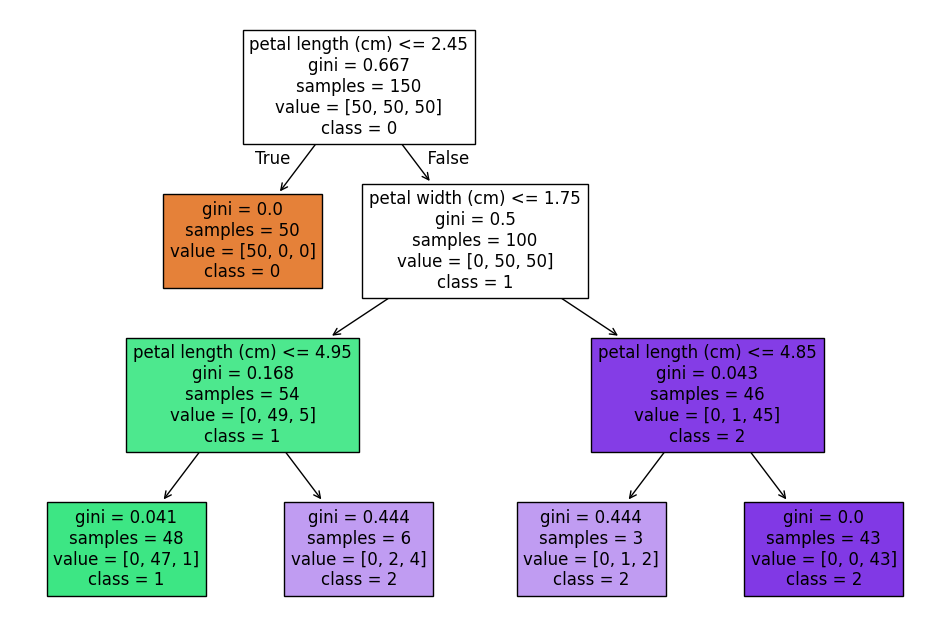

In [24]:
%matplotlib inline
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.preprocessing import LabelEncoder

# Load the dataset from the CSV file
df = pd.read_csv('Iris.csv')

# Assuming the last column is the target and the rest are features
X = df.drop(df.columns[-1], axis=1)
y = df[df.columns[-1]]

# Convert target labels from strings to numerical representations
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
class_names = [str(c) for c in label_encoder.classes_] # Update class_names to the original string labels

# Get feature names from the dataframe
feature_names = X.columns.tolist()


clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=feature_names, class_names=class_names)
plt.show()

In [21]:
profile.to_file("my_data_profile.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
                                                      # ----- DIABETES ------ #

In [25]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
# Separate features (X) and target (y) for the new dataset
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Create a Decision Tree Classifier model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(matrix)

Accuracy: 0.7467532467532467
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Confusion Matrix:
[[75 24]
 [15 40]]


In [ ]:
                                                   # ---- LOAN APPROVAL DATASET ---- #

In [46]:
df1 = pd.read_csv('loan_approval_dataset.csv')
df1.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [47]:
display(df1.columns)

Index(['loan_id', 'no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [48]:
# Separate features (X) and target (y) for the loan approval dataset
X_loan = df1.drop(' loan_status', axis=1)
y_loan = df1[' loan_status']

# Convert categorical features to numerical using one-hot encoding
X_loan = pd.get_dummies(X_loan, columns=[' education', ' self_employed'], drop_first=True)

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split

df1 = pd.read_csv('loan_approval_dataset.csv')

# Separate features (X) and target (y) for the loan approval dataset
X_loan = df1.drop(' loan_status', axis=1)
y_loan = df1[' loan_status']

# Convert categorical features to numerical using one-hot encoding
X_loan = pd.get_dummies(X_loan, columns=[' education', ' self_employed'], drop_first=True)

# Split data into training and testing sets for the loan approval dataset
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(X_loan, y_loan, test_size=0.2, random_state=42)

In [50]:
# Create a Decision Tree Classifier model for the loan approval dataset
model_loan = DecisionTreeClassifier(random_state=42)

# Train the model
model_loan.fit(X_train_loan, y_train_loan)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred_loan = model_loan.predict(X_test_loan)

# Evaluate the model
accuracy_loan = accuracy_score(y_test_loan, y_pred_loan)
report_loan = classification_report(y_test_loan, y_pred_loan)
matrix_loan = confusion_matrix(y_test_loan, y_pred_loan)

print(f"Accuracy: {accuracy_loan}")
print("Classification Report:")
print(report_loan)
print("Confusion Matrix:")
print(matrix_loan)

Accuracy: 0.9754098360655737
Classification Report:
              precision    recall  f1-score   support

    Approved       0.98      0.98      0.98       536
    Rejected       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854

Confusion Matrix:
[[526  10]
 [ 11 307]]
